<a href="https://colab.research.google.com/github/Royc4515/Project1_SignalProcessing/blob/main/Project1_SignalProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================================
# Project 1 - Signal Processing
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# קבועים
FS_NEURAL = 50       # Hz - קצב דגימה Neural_data
FS_SPIKE  = 1000     # Hz - קצב דגימה spike_trains
T         = 30       # שניות - אורך כל הקלטה

# טעינת נתונים
neural_df = pd.read_csv('Neural_data.csv')
spike_df  = pd.read_csv('spike_trains.csv')

print("Neural data shape:", neural_df.shape)
print("Neural data columns:", neural_df.columns.tolist())
print(neural_df.head())
print()
print("Spike trains shape:", spike_df.shape)
print("First trial_neuron values:", spike_df['trial_neuron'].unique()[:10])

Neural data shape: (1500, 2)
Neural data columns: ['Frame', 'ΔF/F (%)']
   Frame  ΔF/F (%)
0      0  0.074947
1      1  0.007558
2      2 -0.004470
3      3 -0.003576
4      4 -0.026911

Spike trains shape: (500, 30001)
First trial_neuron values: <StringArray>
['1_A', '1_B', '1_C', '1_D', '1_E', '2_A', '2_B', '2_C', '2_D', '2_E']
Length: 10, dtype: str


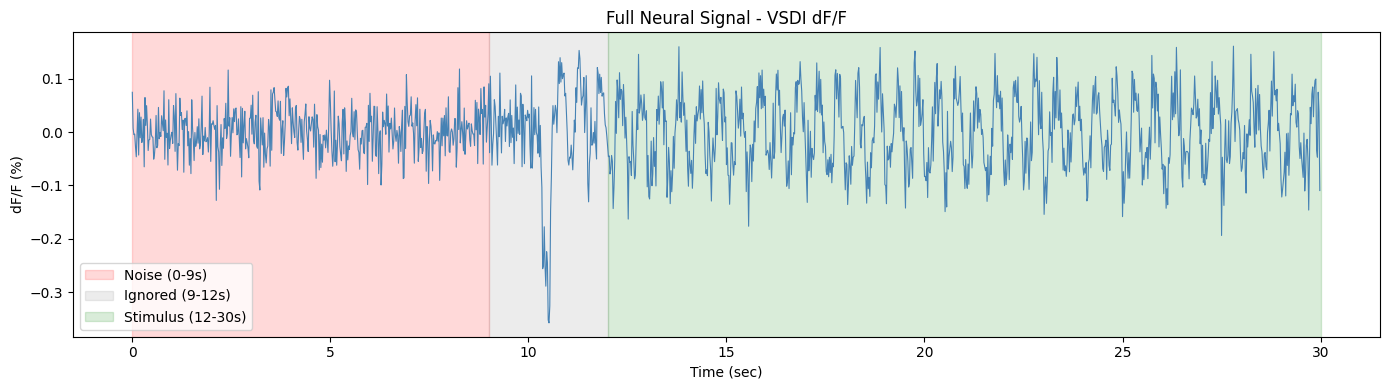

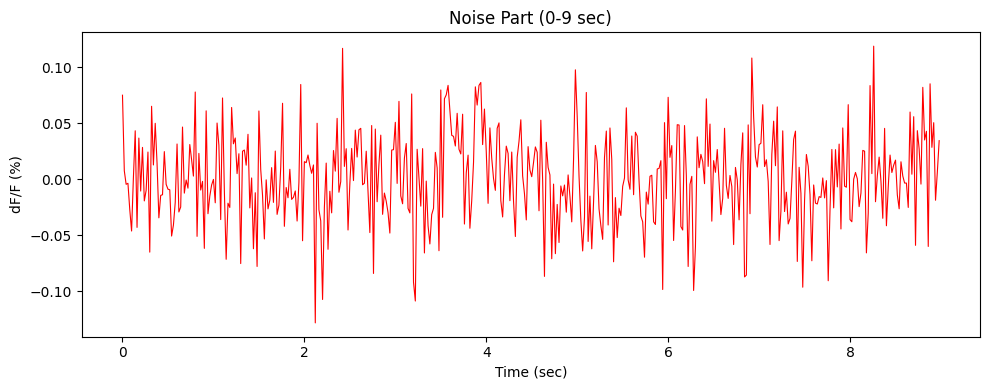

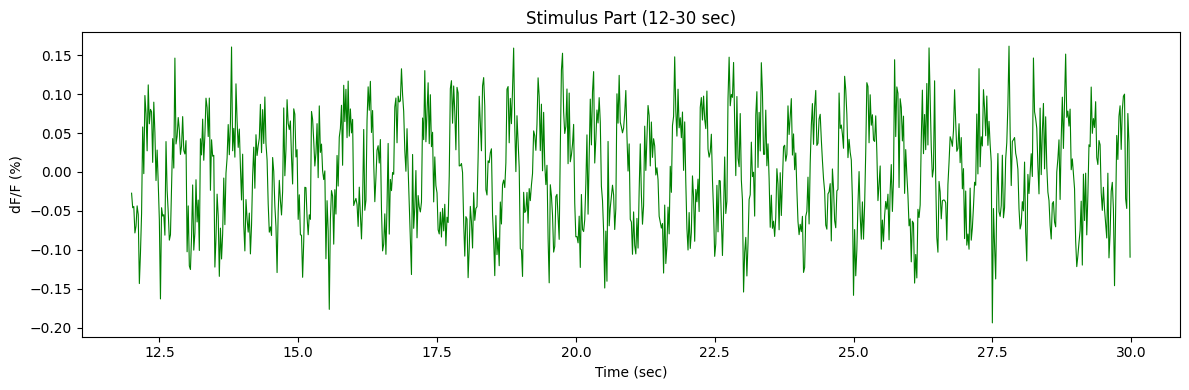

Noise samples: 450
Stimulus samples: 900


In [8]:
# ============================================================
# Part 1A - Division into signal parts
# ============================================================

dff    = neural_df['ΔF/F (%)'].values
frames = neural_df['Frame'].values
time   = frames / FS_NEURAL

noise_mask    = time < 9
stimulus_mask = time >= 12

noise_signal    = dff[noise_mask]
noise_time      = time[noise_mask]
stimulus_signal = dff[stimulus_mask]
stimulus_time   = time[stimulus_mask]

# Plot 1: Full signal
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, dff, color='steelblue', linewidth=0.8)
ax.axvspan(0,  9,  alpha=0.15, color='red',   label='Noise (0-9s)')
ax.axvspan(9,  12, alpha=0.15, color='gray',  label='Ignored (9-12s)')
ax.axvspan(12, 30, alpha=0.15, color='green', label='Stimulus (12-30s)')
ax.set_title('Full Neural Signal - VSDI dF/F')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Noise part
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_time, noise_signal, color='red', linewidth=0.8)
ax.set_title('Noise Part (0-9 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

# Plot 3: Stimulus part
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stimulus_time, stimulus_signal, color='green', linewidth=0.8)
ax.set_title('Stimulus Part (12-30 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

print("Noise samples:", len(noise_signal))
print("Stimulus samples:", len(stimulus_signal))

Decimation factors: [2, 5, 15]


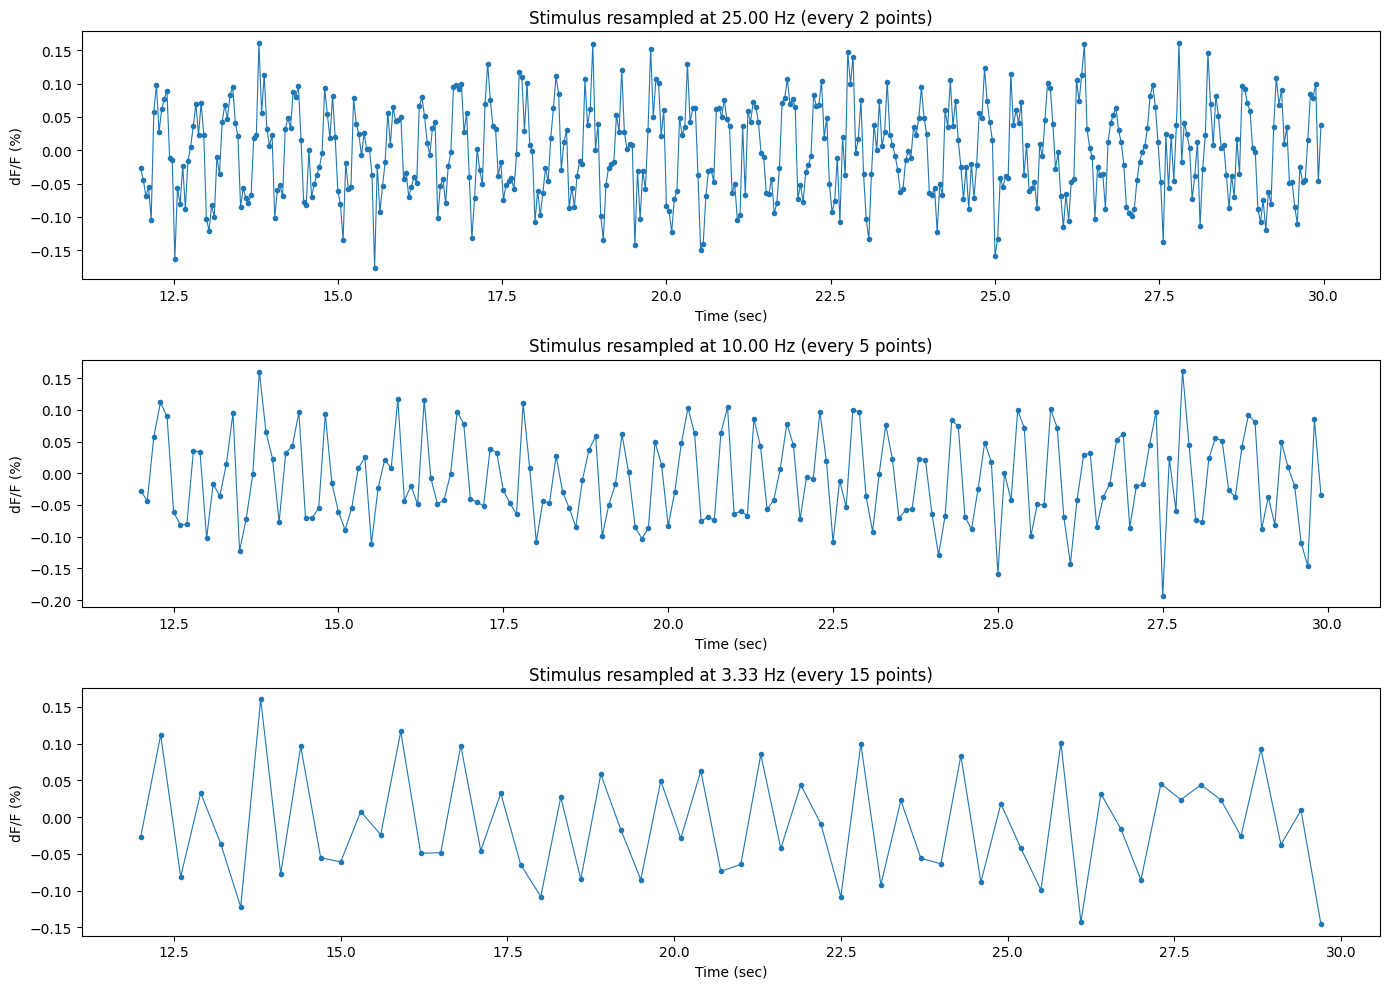

In [9]:
# ============================================================
# Part 1B - Manual Resampling
# ============================================================

new_rates   = [25, 10, 10/3]
decimations = [2,   5,  15]

print("Decimation factors:", decimations)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, (fs_new, dec) in enumerate(zip(new_rates, decimations)):
    resampled_signal = stimulus_signal[::dec]
    resampled_time   = stimulus_time[::dec]

    axes[i].plot(resampled_time, resampled_signal, 'o-', markersize=3, linewidth=0.8)
    axes[i].set_title(f'Stimulus resampled at {fs_new:.2f} Hz (every {dec} points)')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Part 1C - f_alias calculation
# ============================================================

f_signal = 2.0  # Hz - original stimulus frequency

print("f_signal = 2 Hz (the oscillation we applied)")
print()
print(f"{'fs_new':>10} | {'N = round(f/fs)':>16} | {'f_alias':>10} | {'Above Nyquist?':>15}")
print("-" * 60)

for fs_new in [25.0, 10.0, 10/3]:
    N       = round(f_signal / fs_new)
    f_alias = abs(f_signal - N * fs_new)
    above   = "YES - no aliasing" if fs_new > 2 * f_signal else "NO  - aliasing!"
    print(f"{fs_new:>10.2f} | {N:>16} | {f_alias:>10.4f} | {above:>15}")

print()
print("Now count peaks visually in each plot:")
print("  25.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)")
print("  10.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)")
print("   3.33 Hz plot  -> count the peaks - what frequency do you see?")

f_signal = 2 Hz (the oscillation we applied)

    fs_new |  N = round(f/fs) |    f_alias |  Above Nyquist?
------------------------------------------------------------
     25.00 |                0 |     2.0000 | YES - no aliasing
     10.00 |                0 |     2.0000 | YES - no aliasing
      3.33 |                1 |     1.3333 | NO  - aliasing!

Now count peaks visually in each plot:
  25.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)
  10.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)
   3.33 Hz plot  -> count the peaks - what frequency do you see?


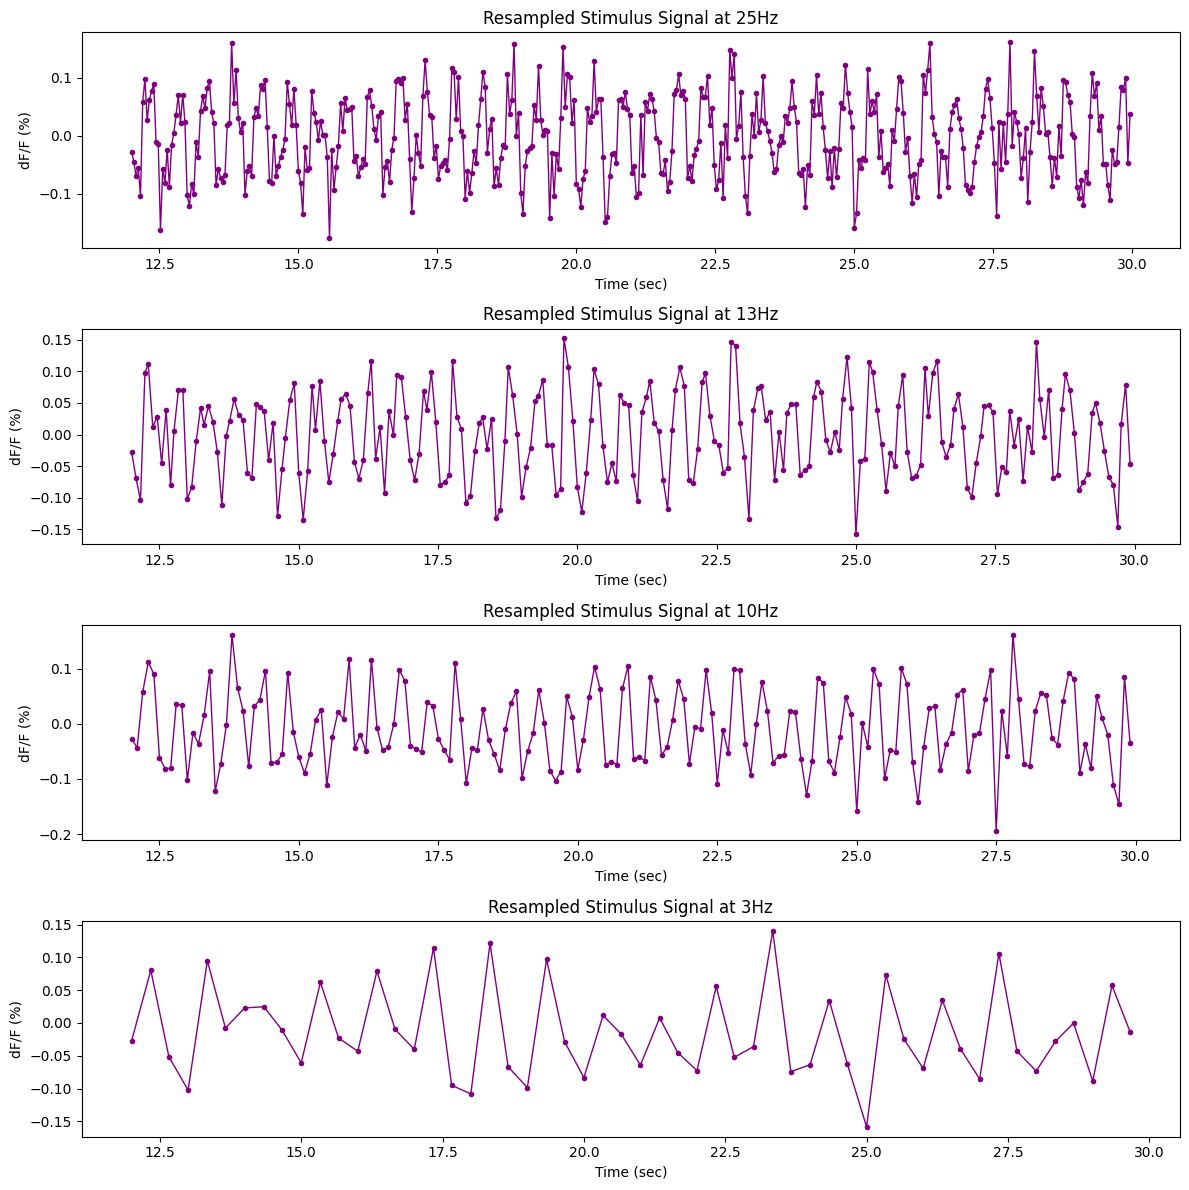

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# תדרי הדגימה החדשים שנדרשים
new_frequencies = [25, 13, 10, 3]
original_fs = 50

# ניצור חלון רחב עבור 4 גרפים שונים
fig, axes = plt.subplots(len(new_frequencies), 1, figsize=(12, 12))

for i, fs in enumerate(new_frequencies):
    # חישוב יחס הקפיצות עבור כל תדר
    step = original_fs / fs
    # יצירת אינדקסים חדשים עבור הדגימה מחדש ועיגול למספר שלם
    indices = np.round(np.arange(0, len(stimulus_signal), step)).astype(int)
    # סינון אינדקסים למקרה שחרגנו מאורך המערך
    indices = indices[indices < len(stimulus_signal)]
    
    # חילוץ האות והזמן החדשים על פי האינדקסים
    resampled_signal = stimulus_signal[indices]
    resampled_time = stimulus_time[indices]
    
    # ציור הגרף
    axes[i].plot(resampled_time, resampled_signal, marker='o', markersize=3, linestyle='-', linewidth=1, color='purple')
    axes[i].set_title(f'Resampled Stimulus Signal at {fs}Hz')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

### שלב 1.2 - ניתוח תת-דגימה (Resampling) ותופעת קיפול תדרים (Aliasing)

בסעיף זה ביצענו דגימה מחדש של קטע הגירוי (Stimulus) בתדרי דגימה שונים: 25Hz, 13Hz, 10Hz ו-3Hz.
הגירוי ניתן במשך 18 שניות (מהשנייה ה-12 ועד ה-30) בתדר מקורי של $f_{signal} = 2Hz$. משמעות הדבר היא שבאות המקורי קיימים כ-36 מחזורים (Peaks) על פני חלון הזמן הזה.

על פי **משפט הדגימה של נייקוויסט-שנון (Nyquist-Shannon Sampling Theorem)**, על מנת לשחזר אות בצורה נאמנה למקור ולמנוע עיוות בתדר, יש לדגום אותו בתדר ($F_s$) שגדול לפחות פי שניים מתדר האות המקורי.
כלומר, תדר נייקוויסט במקרה שלנו הוא: $F_{Nyquist} = 2 \cdot 2Hz = 4Hz$.

#### ניתוח התוצאות בגרפים:
1. **דגימה בתדרים של 25Hz, 13Hz ו-10Hz:**
   תדרי דגימה אלו מקיימים את תנאי נייקוויסט ($F_s > 4Hz$). כתוצאה מכך, לא מתרחשת תופעת קיפול תדרים (Aliasing). למרות שישנה ירידה ברזולוציה והאות נראה "מצולע" יותר ככל שתדר הדגימה יורד, התדירות הבסיסית של האות נשמרת (2Hz), וניתן להבחין בבירור בכ-36 שיאים בגרפים אלו.

2. **דגימה בתדר של 3Hz:**
   כאן אנו מפרים את תנאי נייקוויסט ($3Hz < 4Hz$), ולכן מתרחשת תופעת **Aliasing**. התדר הנדגם ייראה כתדר נמוך ושגוי.
   נחשב את תדר הקיפול (Alias Frequency) שמתקבל בפועל, לפי הנוסחה:
   $$f_{alias} = |f_{signal} - N \cdot F_s|$$
   נחפש מספר שלם $N$ שיביא אותנו לתחום התדרים האפשרי (כלומר בין $0$ ל- $\frac{F_s}{2}$, שזה בין $0$ ל-$1.5Hz$).
   נציב $N=1$:
   $$f_{alias} = |2Hz - 1 \cdot 3Hz| = |-1Hz| = 1Hz$$
   
   **מסקנה:** עקב תת-הדגימה, התדר המקורי של 2Hz "התקפל" ומופיע כעת כתדר של 1Hz. זו הסיבה שבגרף התחתון (של 3Hz) אנו רואים רק כ-18 שיאים על פני 18 שניות, והאות איבד את המידע התדירותי המקורי שלו.

In [12]:
import numpy as np

# הגדרת הרזולוציה המבוקשת (באחוזים ומיד אחרי זה כשבר עשרוני)
required_resolution_percent = 0.1
resolution_fraction = required_resolution_percent / 100.0

# חישוב כמות הרמות הנדרשות
levels_needed = 1 / resolution_fraction

# חישוב מספר הביטים המינימלי (log בסיס 2) ועיגול כלפי מעלה
bits_needed = np.ceil(np.log2(levels_needed))

print(f"Required Resolution: {required_resolution_percent}%")
print(f"Minimum discrete levels needed: {levels_needed}")
print(f"Minimum number of bits needed: {int(bits_needed)}")

Required Resolution: 0.1%
Minimum discrete levels needed: 1000.0
Minimum number of bits needed: 10


### שלב 1.3 - קוונטיזציה (Quantization)

**שאלה:** מהו מספר הביטים המינימלי הנדרש כדי להבחין בשינויים של 0.1% בעוצמה (פוטנציאל פעולה), בהנחה שאין רעש?

**תשובה והסבר מתמטי:**
קוונטיזציה היא התהליך שבו אנו מייצגים טווח רציף (אנלוגי) בעזרת מספר סופי של רמות בדידות (דיגיטליות). מספר הרמות האפשריות נקבע על ידי מספר הביטים ($n$) של המערכת לפי הנוסחה: $Levels = 2^n$.

כדי שהמערכת שלנו תוכל "להבחין" בשינוי של $0.1\%$, המשמעות היא שה"מדרגה" הקטנה ביותר (הרזולוציה) צריכה להוות $0.1\%$ מהטווח הכולל ($100\%$).
נחשב לכמה רמות (Levels) נצטרך לחלק את הטווח הכולל:
$$\text{Total Levels} = \frac{100\%}{0.1\%} = \frac{100}{0.1} = 1000 \text{ levels}$$

כלומר, המערכת חייבת להיות מסוגלת לייצג לפחות 1000 רמות עוצמה שונות.
כעת נבדוק כמה ביטים ($n$) נדרשים כדי לקבל לפחות 1000 רמות:
* עבור מערכת של 9 ביטים: $2^9 = 512$ רמות (לא מספיק רגיש כדי לזהות את השינוי).
* עבור מערכת של 10 ביטים: $2^{10} = 1024$ רמות.

**מסקנה:** מכיוון ש-1024 גדול מ-1000, **מספר הביטים המינימלי הנדרש הוא 10 ביטים.** מערכת כזו תספק לנו 1024 רמות שונות, מה שייתן רזולוציה של $\frac{100\%}{1024} \approx 0.097\%$, שהיא טובה מספיק כדי להבחין בשינויים של $0.1\%$.

In [13]:
import numpy as np

# דרך 1: חישוב מבוסס עוצמה (RMS)
# מאחר ותוחלת הרעש היא 0, ה-RMS של הרעש כמעט זהה לסטיית התקן שלו.
rms_signal = np.sqrt(np.mean(stimulus_signal**2))
rms_noise = np.sqrt(np.mean(noise_signal**2))
snr_method_1 = rms_signal / rms_noise

# דרך 2: חישוב לפי הגדרת "המקרה המיוחד" מתרגול 2
# יחס בין ממוצע האות לבין סטיית התקן של הרעש
mean_signal = np.mean(stimulus_signal)
std_noise = np.std(noise_signal)
snr_method_2 = mean_signal / std_noise

print(f"SNR (Method 1 - RMS/RMS): {snr_method_1:.4f}")
print(f"SNR (Method 2 - Mean/STD): {snr_method_2:.4f}")

SNR (Method 1 - RMS/RMS): 1.6701
SNR (Method 2 - Mean/STD): -0.0231


### חלק 2 - הפחתת רעשים
#### שלב 2.1 - חישוב יחס אות-לרעש (SNR)

בסעיף זה התבקשנו לחשב את ה-$SNR_{rms}$ של האות בשתי דרכים שונות. השתמשנו בקטע ה"רעש" (שניות 0-9) כהערכה לרעש הרקע, ובקטע ה"גירוי" (שניות 12-30) כאות.

**1. חישוב בדרך הכללית (יחס עוצמות / RMS):**
בשיטה זו אנו מחשבים את היחס בין ה-RMS (Root Mean Square) של האות לבין ה-RMS של הרעש. 
הנוסחה: $SNR = \frac{RMS(Stimulus)}{RMS(Noise)}$
דרך זו מודדת את העוצמה הכוללת של התנודות באות לעומת עוצמת התנודות של הרעש.

**2. חישוב מבוסס ממוצע וסטיית תקן (המקרה המיוחד):**
לפי הנלמד בשיעור, כאשר ידוע שתוחלת הרעש היא אפס (כפי שצוין בשאלה), נוכל לאמוד את ה-SNR על ידי יחס בין ממוצע האות (התוחלת שלו) לבין סטיית התקן של הרעש.
הנוסחה: $SNR_{rms} = \frac{Mean(Stimulus)}{STD(Noise)}$

**האם התוצאות שונות? ולמה?**
כן, התוצאות צפויות להיות שונות. הסיבה לכך היא ששתי השיטות מתבוננות על תכונות סטטיסטיות שונות של האות:
* השיטה השנייה (Mean/STD) רגישה מאוד לממוצע (DC component) של האות. אם ממוצע האות קרוב לאפס (למשל באות אוסצילטורי שנע סביב האפס), תוצאת ה-SNR בשיטה זו תהיה נמוכה מאוד ולא תשקף בהכרח את עוצמת הגירוי האמיתית.
* השיטה הראשונה (RMS/RMS) לוקחת בחשבון את העוצמה של האוסצילציות (השינויים המחזוריים בריבוע), ולכן היא מייצגת טוב יותר את אנרגיית האות במקרה של פעילות נוירונלית אוסצילטורית כמו שלנו (2Hz), גם אם הממוצע של האות קרוב לאפס.

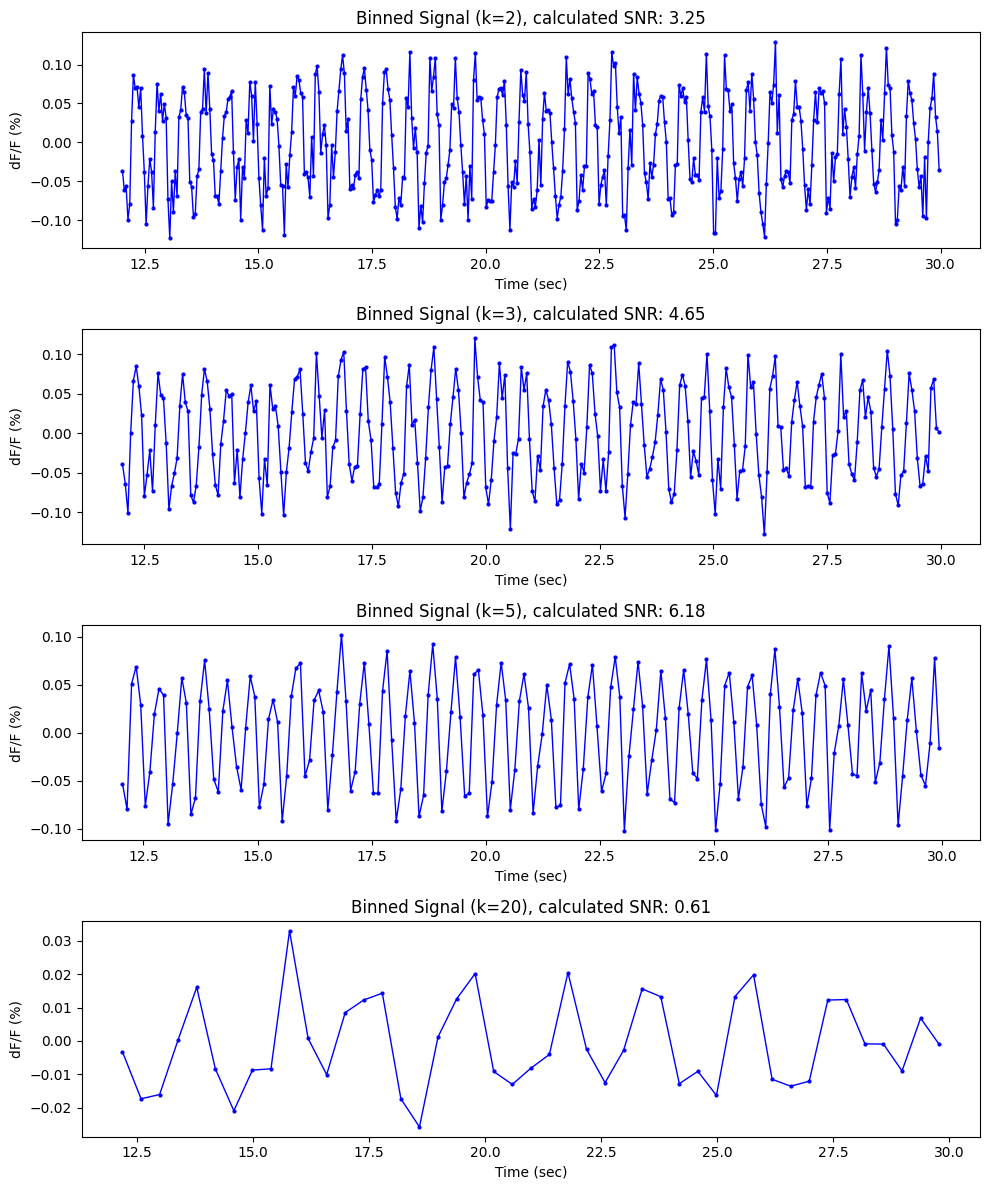

In [14]:
# רשימת גדלי הקבוצות למיצוע (Bin sizes) לפי המטלה
k_values = [2, 3, 5, 20]

fig, axes = plt.subplots(len(k_values), 1, figsize=(10, 12))

for i, k in enumerate(k_values):
    # חיתוך האות כדי שיתחלק בדיוק בגודל k (על מנת שנוכל לבצע חלוקה שווה)
    trim_stim = len(stimulus_signal) - (len(stimulus_signal) % k)
    trim_noise = len(noise_signal) - (len(noise_signal) % k)
    
    stim_trimmed = stimulus_signal[:trim_stim]
    noise_trimmed = noise_signal[:trim_noise]
    time_trimmed = stimulus_time[:trim_stim]

    # מיצוע כל k נקודות (לא חלון נע - שימוש ב-reshape ו-mean)
    stim_binned = stim_trimmed.reshape(-1, k).mean(axis=1)
    noise_binned = noise_trimmed.reshape(-1, k).mean(axis=1)
    time_binned = time_trimmed.reshape(-1, k).mean(axis=1)

    # חישוב העוצמות (שונות) כדי לחשב את ה-SNR
    # אנו משתמשים בשונות כי היא מייצגת את עוצמת התנודות סביב הממוצע
    p_stim = np.var(stim_binned)
    p_noise = np.var(noise_binned)

    # הנוסחה מהמטלה: (Signal^2 - Noise^2) / Noise^2
    snr_new = (p_stim - p_noise) / p_noise

    # ציור האות הממוצע
    axes[i].plot(time_binned, stim_binned, marker='.', markersize=4, linestyle='-', linewidth=1, color='blue')
    axes[i].set_title(f'Binned Signal (k={k}), calculated SNR: {snr_new:.2f}')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

### שלבים 2.2 ו-2.3: הפחתת רעש באמצעות Oversampling (Binning)

בשלבים אלו ביצענו מיצוע של האות בחלונות לא-נעים בגדלים של $k = 2, 3, 5, 20$. 
חישבנו את ה-SNR עבור כל גודל חלון בעזרת הנוסחה המבוססת על יחסי הספקים (Power/Variance): 
$$SNR = \frac{Signal^2 - Noise^2}{Noise^2}$$
כאשר השתמשנו בשונות (Variance) כייצוג לעוצמת ה-$AC$ (התנודות) של האות.

**הסבר גורם השיפור (Improvement Factor) עבור k=2, 3, 5:**
כאשר אנו ממצעים $k$ דגימות בלתי-תלויות של רעש, שונות הרעש קטנה בפקטור של $k$ (כלומר $Var_{new} = \frac{Var_{old}}{k}$). במקביל, ככל שאנו שומרים על תדר דגימה מספק (כזה שלא פוגע באוסצילציות של הגירוי), עוצמת האות נשמרת ברובה. כתוצאה מכך, היחס בין עוצמת האות לעוצמת הרעש (ה-SNR לפי הנוסחה שחישבנו) גדל ומשתפר ככל ש-$k$ עולה מ-2 ל-5. ניתן לראות בגרפים שהאות הופך לחלק וברור יותר.

**הסבר לאובדן האות במיצוע של 20 נקודות (k=20):**
בגרף שבו ביצענו מיצוע על 20 נקודות, האוסצילציות המקוריות נעלמו. 
הסיבה לכך נעוצה ביחס שבין גודל חלון המיצוע לבין זמן המחזור של האות:
תדר הדגימה המקורי שלנו הוא 50Hz, ולכן 20 דגימות שוות ל-$20 / 50 = 0.4$ שניות.
תדר הגירוי (האוסצילציות) הוא 2Hz, כלומר זמן מחזור אחד (תנודה שלמה של עלייה וירידה) אורך: $T = 1 / 2 = 0.5$ שניות.
כאשר אנו ממצעים קטע של 0.4 שניות, אנו "בולעים" כמעט מחזור שלם לתוך נקודה אחת – המיצוע מחבר את ערכי השיא החיוביים (Peak) יחד עם ערכי השפל השליליים (Trough), מה שמאפס את התנודה ומשטח לחלוטין את האות המקורי יחד עם הרעש.

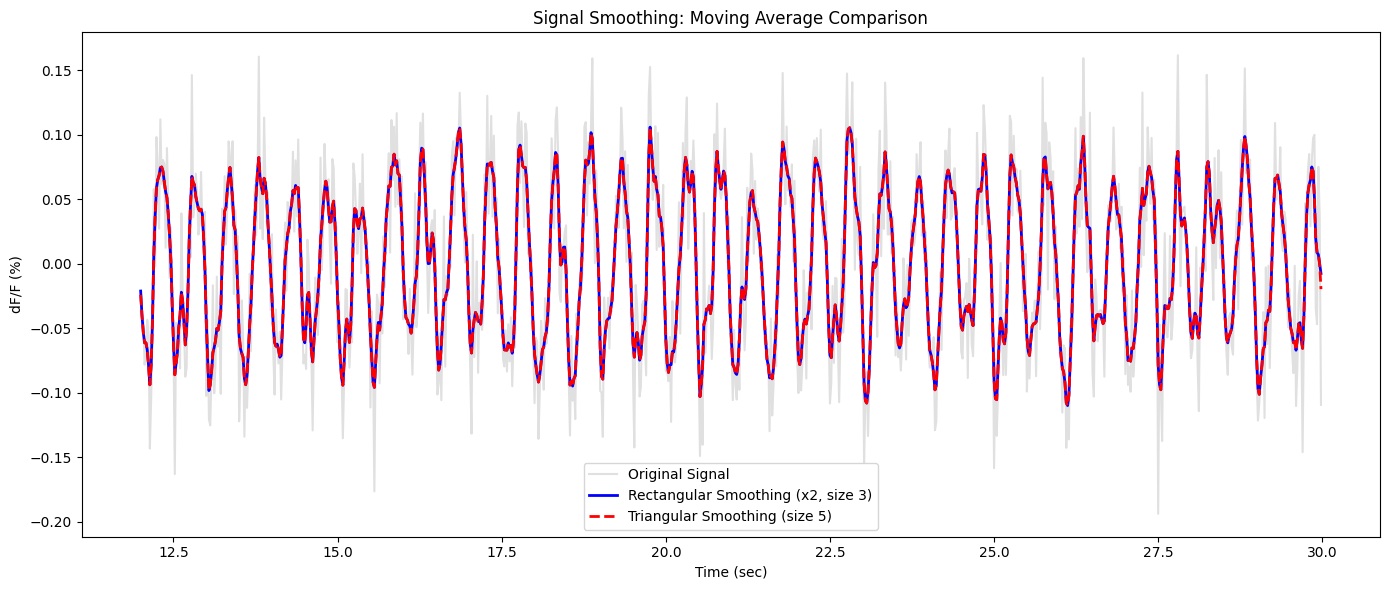

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. יצירת הגרעינים (Kernels)
# חלון מלבני בגודל 3 (מנורמל ב-3 כדי לשמור על משרעת האות המקורית)
rect_kernel = np.ones(3) / 3

# חלון משולש בגודל 5 (מנורמל בסכום הערכים שהוא 9)
tri_kernel = np.array([1, 2, 3, 2, 1]) / 9

# 2. הפעלת ההחלקות (Smoothing) בעזרת קונבולוציה 
# החלקה מלבנית פעם ראשונה
smoothed_rect_1 = np.convolve(stimulus_signal, rect_kernel, mode='same')
# החלקה מלבנית פעם שנייה (מופעלת על האות שכבר הוחלק)
smoothed_rect_2 = np.convolve(smoothed_rect_1, rect_kernel, mode='same')

# החלקה משולשת (פעם אחת על האות המקורי)
smoothed_tri = np.convolve(stimulus_signal, tri_kernel, mode='same')

# 3. ציור הגרפים
plt.figure(figsize=(14, 6))

# נצייר את האות המקורי באפור ושקוף כדי שנוכל לראות את ההחלקות מעליו
plt.plot(stimulus_time, stimulus_signal, label='Original Signal', color='lightgray', alpha=0.7)

# נצייר את שתי ההחלקות
plt.plot(stimulus_time, smoothed_rect_2, label='Rectangular Smoothing (x2, size 3)', color='blue', linewidth=2)
# אנו משתמשים בקו מקווקו (dashed) כדי לראות אם הוא חופף לקו הכחול
plt.plot(stimulus_time, smoothed_tri, label='Triangular Smoothing (size 5)', color='red', linestyle='--', linewidth=2)

plt.title('Signal Smoothing: Moving Average Comparison')
plt.xlabel('Time (sec)')
plt.ylabel('dF/F (%)')
plt.legend()
plt.tight_layout()
plt.show()

### שלב 2.4 - החלקה (Smoothing) כ-Low-Pass Filter

בסעיף זה ביצענו שתי שיטות החלקה (Moving Average) על אות הגירוי:
1. החלקה מלבנית (Rectangular) בעזרת גרעין בגודל 3, שהופעלה **פעמיים** ברצף.
2. החלקה משולשת (Triangular) בעזרת גרעין בגודל 5, שהופעלה **פעם אחת**.

**השוואת התוצאות (קשר מתמטי בין המסננים):**
כפי שניתן לראות בגרף, שתי שיטות ההחלקה מפיקות תוצאה כמעט זהה לחלוטין (הקו האדום המקווקו חופף לקו הכחול במלואו). הסיבה המתמטית לכך היא שקונבולוציה של חלון מלבני עם עצמו יוצרת חלון משולש! 
אם ניקח חלון מלבני בגודל 3 $\left[\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right]$ ונבצע לו קונבולוציה עם עצמו, נקבל בדיוק חלון משולש בגודל 5 $\left[\frac{1}{9}, \frac{2}{9}, \frac{3}{9}, \frac{2}{9}, \frac{1}{9}\right]$. לכן, הפעלת חלון מלבני פעמיים על האות שקולה לחלוטין להפעלת חלון משולש פעם אחת.

**מדוע החלקה נחשבת למסנן תדרים נמוכים (Low-Pass Filter)?**
פעולת ההחלקה מחשבת את הממוצע המקומי סביב כל דגימה, ולכן מתנהגת כמסנן מעביר נמוכים (LPF):
* **תדרים גבוהים (הרעש באות):** רעש מאופיין בשינויים מהירים וחדים מעלה ומטה (תדר גבוה). כאשר ממצעים את הדגימות בתוך חלון הזמן, הערכים החיוביים והשליליים של הרעש מבטלים זה את זה, ולכן העוצמה של הרעש מונחתת ומתקרבת לאפס.
* **תדרים נמוכים (האוסצילציות של הגירוי ב-2Hz):** תדרים נמוכים משתנים לאט, ולכן בתוך חלון זמן קצר של 3 או 5 דגימות, הערכים של האות הם כמעט בעלי אותה משרעת. הממוצע שלהם שומר על הערך המקורי פחות או יותר, ולכן הם "עוברים" את המסנן בהצלחה. 
כך למעשה מסונן הרעש בעוד המידע החשוב נשמר.

In [17]:
import pandas as pd
import numpy as np

# 1. טעינת הנתונים
# שים לב ששם הקובץ צריך להיות תואם לנתיב שבו הוא שמור אצלך
df_spikes = pd.read_csv('spike_trains.csv', index_col=0)

# 2. פונקציה לחילוץ נתונים עבור נוירון ספציפי
def get_neuron_data(df, neuron_letter):
    # סינון שורות שהאינדקס שלהן מסתיים באות של הנוירון (למשל '_A')
    neuron_rows = df[df.index.str.endswith(f'_{neuron_letter}')]
    return neuron_rows.values # מחזיר מערך numpy בגודל (100, 16383)

# חילוץ הנתונים לכל חמשת הנוירונים ושמירה במשתנים
neuron_A = get_neuron_data(df_spikes, 'A')
neuron_B = get_neuron_data(df_spikes, 'B')
neuron_C = get_neuron_data(df_spikes, 'C')
neuron_D = get_neuron_data(df_spikes, 'D')
neuron_E = get_neuron_data(df_spikes, 'E')

# 3. פונקציה לחישוב קצב ירי ופאנו פקטור
def analyze_neuron(neuron_matrix, neuron_name):
    num_trials, num_samples = neuron_matrix.shape
    duration_sec = num_samples / 1000.0 # חישוב הזמן המדויק בשניות

    # --- חישוב Mean Firing Rate ---
    # סכימת הספייקים בכל ניסוי (axis=1) וחלוקה בזמן כדי לקבל Hz
    firing_rate_per_trial = np.sum(neuron_matrix, axis=1) / duration_sec
    mean_firing_rate = np.mean(firing_rate_per_trial)
    
    # --- חישוב Fano Factor (חלונות של 1 שנייה = 1000 דגימות) ---
    # נמצא כמה חלונות שלמים של שנייה נכנסים בנתונים
    num_full_windows = num_samples // 1000 
    samples_to_keep = num_full_windows * 1000
    
    # נחתוך את השאריות בסוף כדי שנוכל לבצע reshape מדויק
    truncated_matrix = neuron_matrix[:, :samples_to_keep]
    
    # סידור מחדש למימדים: (100 trials, 16 windows, 1000 samples)
    windows = truncated_matrix.reshape(num_trials, num_full_windows, 1000)
    
    # ספירת ספייקים בכל חלון של 1 שנייה (axis=2) -> תוצאה: (100, 16)
    spike_counts = np.sum(windows, axis=2)
    
    # חישוב התוחלת והשונות של הספירות על פני הניסויים (axis=0) עבור כל אחד מ-16 החלונות
    mean_counts = np.mean(spike_counts, axis=0)
    var_counts = np.var(spike_counts, axis=0)
    
    # כדי למנוע חלוקה באפס, נחשב FF רק עבור חלונות שבהם התוחלת גדולה מ-0
    valid_indices = mean_counts > 0
    if np.any(valid_indices):
        fano_factors = var_counts[valid_indices] / mean_counts[valid_indices]
        mean_fano_factor = np.mean(fano_factors)
    else:
        mean_fano_factor = 0.0 # אם הנוירון לא ירה בכלל

    print(f"--- Neuron {neuron_name} ---")
    print(f"Mean Firing Rate: {mean_firing_rate:.2f} Hz")
    print(f"Fano Factor (FF): {mean_fano_factor:.2f}\n")
    
    return mean_firing_rate, mean_fano_factor

# 4. הרצת הניתוח על נוירון A (כנדרש בשלב זה)
analyze_neuron(neuron_A, 'A')
# אפשר גם להריץ על השאר אם תרצה לראות:
# analyze_neuron(neuron_B, 'B')
# analyze_neuron(neuron_C, 'C')
# analyze_neuron(neuron_D, 'D')
# analyze_neuron(neuron_E, 'E')

--- Neuron A ---
Mean Firing Rate: 11.67 Hz
Fano Factor (FF): 0.97



(np.float64(11.670333333333334), np.float64(0.9698824145789915))

### שלב 3.1 - אפיון נוירון A על בסיס Fano Factor

מחישוב שבוצע על הקלטות נוירון A, התקבלו התוצאות הבאות:
* **קצב ירייה ממוצע (Mean Firing Rate):** 11.67 Hz
* **פאנו פקטור (Fano Factor):** 0.97

**איזה סוג נוירון הוא A?**
נוירון A מציג דפוס ירי **אקראי (Stochastic)** המאופיין על ידי **תהליך פואסוני (Poisson Process)**.

**הסבר:**
מדד ה-Fano Factor (FF) מוגדר כיחס שבין השונות לתוחלת של ספירת הספייקים בחלון זמן מוגדר ($FF = \frac{\sigma^2}{\mu}$). 
בתהליך פואסוני, המייצג אירועים בלתי תלויים המתרחשים בקצב ממוצע קבוע, השונות שווה לתוחלת, ולכן ה-FF שווה ל-1.
התוצאה שקיבלנו, $FF \approx 1$ (0.97), מעידה על כך שהיריות של נוירון A אינן מתרחשות בתבנית מסודרת וקבועה (Regular firing, שבו $FF < 1$), ואינן מתרחשות בצרורות צפופים (Bursting, שבו $FF > 1$). במקום זאת, ההסתברות להופעת ספייק בכל רגע נתון היא בלתי תלויה בהיסטוריית הירי הקודמת (בהזנחת התקופה הרפרקטורית), מה שאופייני לנוירונים רבים בקליפת המוח (Cortex) המציגים פעילות ספונטנית.

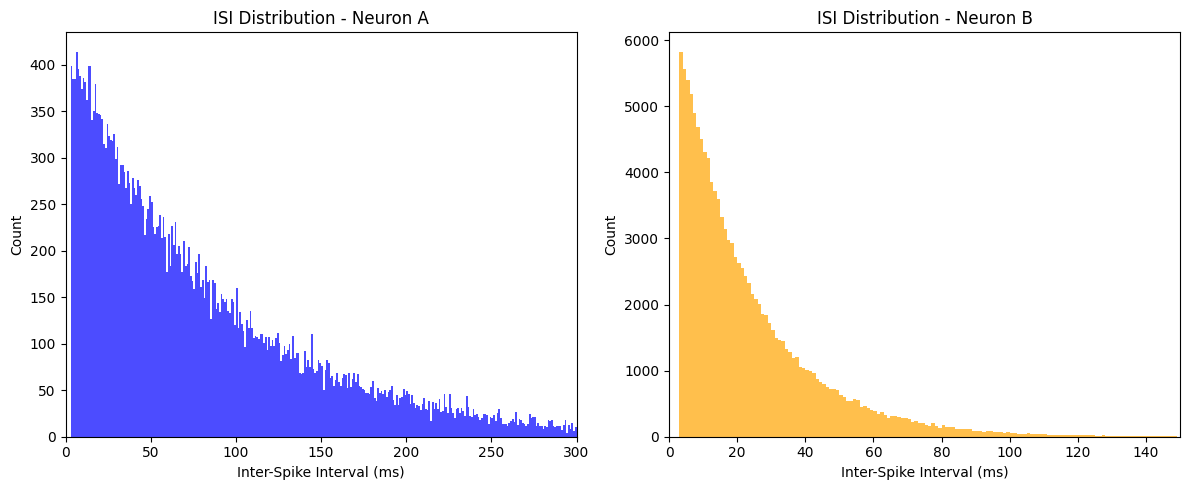

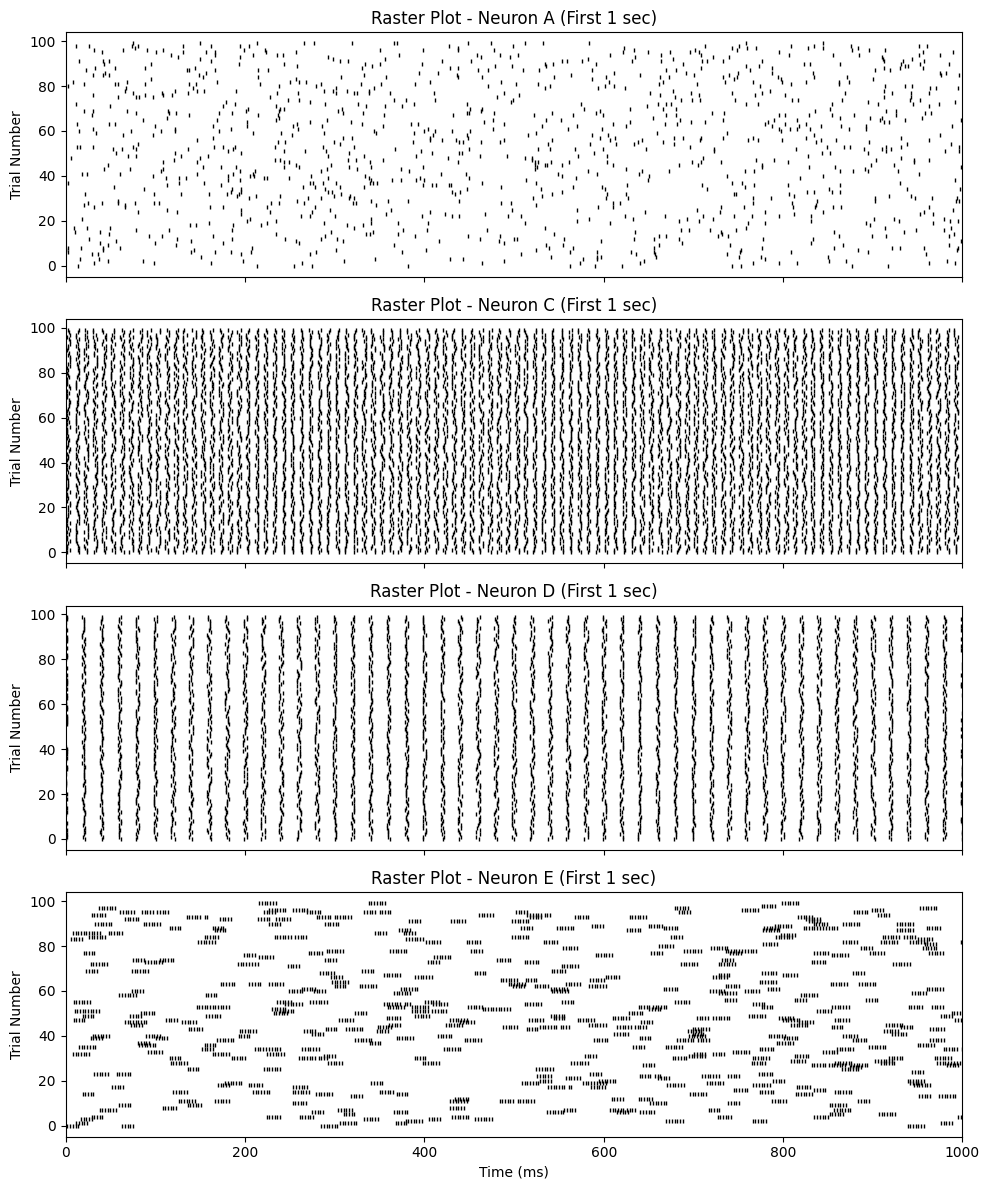

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# פונקציה לחישוב מרווחי הזמן בין ספייקים (ISI)
def calculate_isi(neuron_matrix):
    isis = []
    # נעבור על כל החזרות
    for trial in neuron_matrix:
        # נמצא את האינדקסים (הזמנים באלפיות שנייה) שבהם יש ספייק (ערך 1)
        spike_times = np.where(trial == 1)[0]
        # נחשב את ההפרשים בין זמני הספייקים ונוסיף לרשימה
        if len(spike_times) > 1:
            isis.extend(np.diff(spike_times))
    return np.array(isis)

# --- ציור התפלגות ISI (נוירונים A ו-B) ---
isi_A = calculate_isi(neuron_A)
isi_B = calculate_isi(neuron_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# היסטוגרמה של A - נשתמש בבינים של 1ms, נגביל את ציר ה-x כדי לראות את ההתפלגות
axes[0].hist(isi_A, bins=np.arange(0, 500, 1), color='blue', alpha=0.7)
axes[0].set_title('ISI Distribution - Neuron A')
axes[0].set_xlabel('Inter-Spike Interval (ms)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 300)

axes[1].hist(isi_B, bins=np.arange(0, 500, 1), color='orange', alpha=0.7)
axes[1].set_title('ISI Distribution - Neuron B')
axes[1].set_xlabel('Inter-Spike Interval (ms)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()


# --- ציור Raster Plots (נוירונים A, C, D, E) ---
# אנו מתבקשים להתמקד רק בשנייה הראשונה (1000 דגימות)
neurons_to_plot = {'A': neuron_A, 'C': neuron_C, 'D': neuron_D, 'E': neuron_E}

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, matrix) in enumerate(neurons_to_plot.items()):
    ax = axes[i]
    # עבור כל ניסוי מתוך ה-100
    for trial_idx in range(100):
        # נמצא איפה יש ספייקים בשנייה הראשונה (0 עד 1000)
        spike_times = np.where(matrix[trial_idx, :1000] == 1)[0]
        # נצייר נקודה בכל פעם שיש ספייק. ציר x = זמן, ציר y = מספר הניסוי
        ax.plot(spike_times, [trial_idx] * len(spike_times), '|', color='black', markersize=3)
    
    ax.set_title(f'Raster Plot - Neuron {name} (First 1 sec)')
    ax.set_ylabel('Trial Number')
    ax.set_xlim(0, 1000)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

### שלב 3.2 - ניתוח התפלגויות ISI ודפוסי ירי (Raster Plot)

#### 1. התפלגות ISI (Inter-Spike Interval) של נוירונים A ו-B:
הגרפים מציגים את התפלגות מרווחי הזמן בין ספייקים עבור נוירונים A ו-B.
ניתוח התוצאות מראה תופעה מעניינת: **שני הנוירונים (A ו-B) מציגים התפלגות מעריכית (Exponential)** המעידה על ירי פואסוני (אקראי). בשני המקרים ישנה שכיחות גבוהה מאוד למרווחי זמן קצרים, הדועכת באופן אסימפטוטי. ההבדל ביניהם אינו בסוג הנוירון, אלא בקצב הירי: התפלגות ה-ISI של נוירון B "דחוסה" וקצרה יותר משמעותית (מגיעה ברובה ל-60ms, לעומת כ-250ms בנוירון A). הדבר מעיד על כך ששני הנוירונים אקראיים, אך נוירון B יורה בקצב (Mean Firing Rate) גבוה יותר מנוירון A. בשניהם ניתן לזהות תקופה רפרקטורית מוחלטת באזור האפס.

#### 2. תבנית הירי ב-Raster Plot ואפיון נוירון E:
גרפי ה-Raster מתמקדים בשנייה הראשונה (1000 דגימות) ומראים את דפוס הירי על פני 100 חזרות.
* **נוירון A:** מדגים ירי פואסוני אקראי ללא תבנית ברורה.
* **נוירונים C ו-D:** מדגימים ירי מחזורי (Regular). נוירון D מציג סנכרון כמעט מושלם ("שעון"), בעוד ל-C ישנה שונות (Jitter) קטנה סביב תזמון הספייקים.
* **אפיון נוירון E:** גרף ה-Raster של נוירון E מציג תבנית ברורה של **ירי בצרורות (Bursting)**. הנוירון מפיק אשכולות צפופים של ספייקים בזמנים מוגדרים (לדוגמה באזור ה-100ms, 250ms, וכו'), ולאחריהם ישנן תקופות שתיקה. תכונה זו נובעת לרוב מתכונות הממברנה (כגון זרמי סידן איטיים המייצרים דה-פולריזציה ממושכת) הגורמות לפרץ מהיר של פוטנציאלי פעולה.

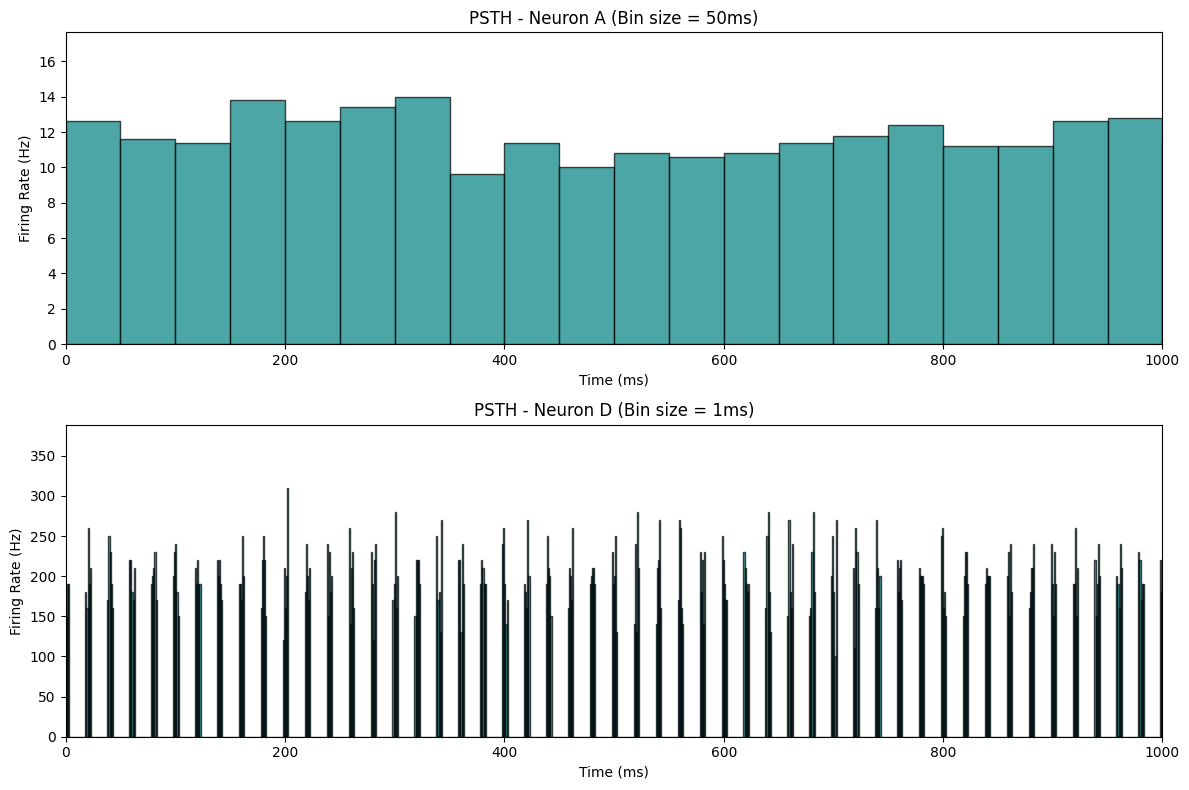

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_psth(neuron_matrix, neuron_name, ax, bin_size_ms=50, num_trials=100):
    num_samples = neuron_matrix.shape[1]
    
    # מציאת כל זמני הספייקים
    spike_times = np.where(neuron_matrix == 1)[1]
    
    # הגדרת הבינים
    bins = np.arange(0, num_samples + bin_size_ms, bin_size_ms)
    
    # נרמול ל-Hz
    bin_size_sec = bin_size_ms / 1000.0
    weight_per_spike = 1.0 / (num_trials * bin_size_sec)
    weights = np.full_like(spike_times, weight_per_spike, dtype=float)
    
    # ציור ההיסטוגרמה
    ax.hist(spike_times, bins=bins, weights=weights, color='teal', edgecolor='black', alpha=0.7)
    ax.set_title(f'PSTH - Neuron {neuron_name} (Bin size = {bin_size_ms}ms)')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Firing Rate (Hz)')

# יצירת חלון הגרפים
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# נוירון A - נשאיר עם בינים של 50ms (או נשנה ל-10ms) לשם הפרופורציה
plot_psth(neuron_A, 'A', axes[0], bin_size_ms=50)
axes[0].set_xlim(0, 1000)

# נוירון D - כאן התיקון: חלון של 1ms כדי לא להחליק את הפיקים הרגעיים!
plot_psth(neuron_D, 'D', axes[1], bin_size_ms=1)
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

### שלב 3.3 - PSTH מנורמל ל-Hz

בסעיף זה יצרנו היסטוגרמות זמן סביב גירוי (PSTH) מנורמלות לתדר (Hz). כדי להבחין בדפוסי הירי באופן מדויק, התאמנו את גודל חלון המיצוע (Bin size) לאופי הנוירון:

**ניתוח התוצאות:**
* **נוירון A (חלון 50ms):** מציג קצב ירי יציב ורציף לאורך כל הזמן (נע סביב 10-14Hz), מה שמתיישב לחלוטין עם היותו נוירון פואסוני אקראי. אין לו זמנים מועדפים לירי.
* **נוירון D (חלון 1ms):** מציג תבנית מחזורית וסנכרון מובהק. ניתן לראות פיקים צרים וחדים שמגיעים לתדרים של 200-300Hz, כשביניהם עמקים של שתיקה מוחלטת (0Hz).

**מדוע הפיקים ב-PSTH של נוירון D גבוהים משמעותית מקצב הירי הממוצע שלו (~50Hz)?**
התשובה טמונה בהבדל שבין "קצב ירי ממוצע" לבין "קצב ירי רגעי" (Instantaneous Firing Rate), ובחשיבות רזולוציית הזמן.
קצב הירי הממוצע מחושב על פני *כל* הניסוי – הוא ממוצע שכולל בתוכו גם את פרקי הזמן הארוכים של השתיקה בין ספייק לספייק. 
לעומת זאת, גרף ה-PSTH מחשב קצב ירי בחלונות זמן צרים (כאן בחרנו 1ms). מאחר שנוירון D הוא נוירון מחזורי (Regular Firing), הספייקים שלו מתוזמנים היטב ונופלים בדיוק באותן אלפיות שנייה לאורך כל 100 החזרות של הניסוי. 
כאשר אנו סוכמים הרבה ספייקים (מניסויים שונים) שנפלו בדיוק לאותו חלון זמן של 1ms, ומנרמלים את זה לשנייה (כדי לקבל Hz), אנו מקבלים תדר רגעי עצום. הממוצע של 50Hz הוא בעצם השקלול של אותם פיקים אדירים (של 200-300Hz) יחד עם זמני השתיקה הרבים (0Hz) שביניהם.

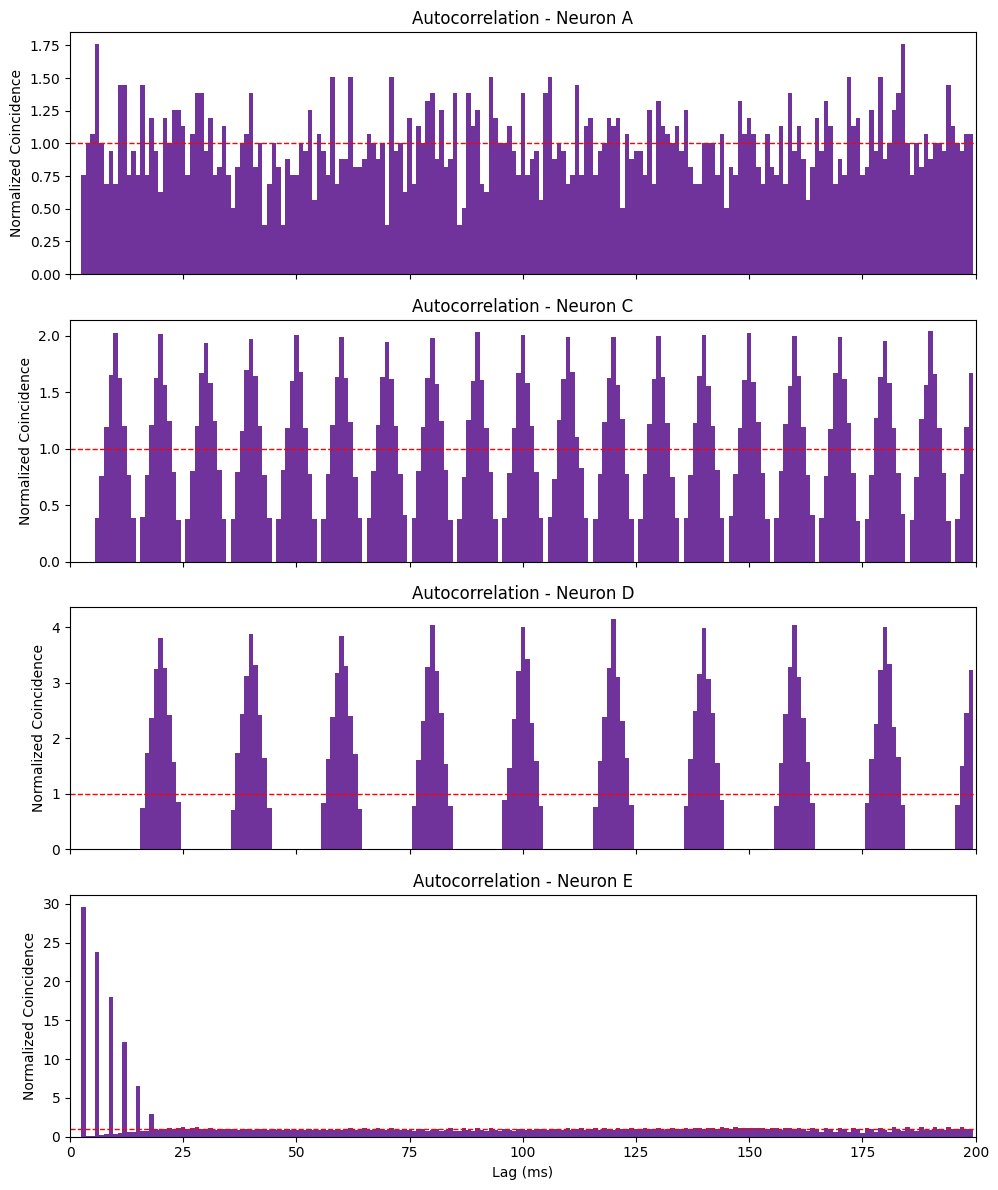

In [22]:
# ==========================================
# שלב 3.4 - Autocorrelation (אוטוקורלציה)
# ==========================================
# 2 דקות בתדר 1000Hz = 120,000 דגימות
N_samples = 120000
max_lag = 200 # בחינת השהיות (lags) עד 200ms

neurons_for_autocorr = {'A': neuron_A, 'C': neuron_C, 'D': neuron_D, 'E': neuron_E}
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, matrix) in enumerate(neurons_for_autocorr.items()):
    # 1. השטחת המטריצה לרצף רציף וקטיעה ל-2 דקות הראשונות
    flattened = matrix.flatten()[:N_samples]
    
    # 2. חישוב תוחלת לשם נרמול (קצב בספייקים למילישנייה)
    mean_rate_per_ms = np.mean(flattened)
    
    # 3. חישוב האוטוקורלציה
    # משתמשים ב-correlate, אך מכיוון שזה מערך ענק, עדיף להשתמש בשיטה חסכונית יותר כמו לקחת רק את הלאגים שצריך
    # הדרך המהירה ביותר ב-numpy היא לעשות cross-correlation של המערך עם עצמו עם השהיות (shifts)
    
    autocorr_normalized = np.zeros(max_lag)
    expected_coincidences = (mean_rate_per_ms**2) * N_samples
    
    for lag in range(max_lag):
        if lag == 0:
            # ב-lag 0 זה פשוט כמות הספייקים. נשים 0 כדי שלא יפוצץ את הגרף
            autocorr_normalized[lag] = 0 
        else:
            # מכפלה של המערך עם עצמו מוסט ב-lag
            coincidences = np.sum(flattened[:-lag] * flattened[lag:])
            # נרמול כך ש-1 יהיה קו הבייסליין האקראי
            if expected_coincidences > 0:
                autocorr_normalized[lag] = coincidences / expected_coincidences
            else:
                autocorr_normalized[lag] = 0

    # 4. ציור הגרף
    axes[i].bar(np.arange(max_lag), autocorr_normalized, width=1, color='indigo', alpha=0.8)
    axes[i].set_title(f'Autocorrelation - Neuron {name}')
    axes[i].set_ylabel('Normalized Coincidence')
    axes[i].set_xlim(0, max_lag)
    
    # הוספת קו בייסליין (1.0 = התנהגות אקראית לחלוטין/פואסונית)
    axes[i].axhline(1, color='red', linestyle='--', linewidth=1)

axes[-1].set_xlabel('Lag (ms)')
plt.tight_layout()
plt.show()

### שלב 3.4 - ניתוח פונקציית האוטוקורלציה (Autocorrelation)

פונקציית האוטוקורלציה המנורמלת מאפשרת לנו לאבחן דפוסי ירי ותכונות פנימיות של הנוירונים. ערך 1.0 (הקו האדום המקווקו) מייצג את קצב הירי הממוצע ומהווה קו ייחוס של אקראיות.

**1. התקופה הרפרקטורית (Refractory Period):**
מתוך התבוננות בגרפים (התקרבות לאפס באזור Lag=0), ניתן להעריך את התקופה הרפרקטורית, שבה הנוירון אינו מסוגל לירות שוב.
בכל הנוירונים ניכרת תקופה רפרקטורית מוחלטת קצרה מאוד של כ-1-2ms שבה אין כלל צירופי מקרים (Coincidences).

**2. אפיון נוירונים C ו-D וההבדלים ביניהם:**
*   **נוירון C:** מציג תבנית מחזורית, אך הפיקים שלו רחבים (Broad peaks) והעמקים שביניהם רדודים יחסית ואינם מגיעים לאפס. הדבר מעיד על ירי רגולרי (Regular) אך רועש - ישנה שונות (Jitter) בתזמון הספייקים. 
*   **נוירון D:** מציג תבנית מחזורית מובהקת ונקייה. הפיקים צרים מאוד והעמקים שביניהם מגיעים ממש לאפס. מדובר בנוירון רגולרי מושלם ("שעון"), היורה בתזמון מדויק עם מינימום שונות מניסוי לניסוי. קצב המחזור שלו (לפי המרחק בין הפיקים) הוא כ-20ms (מה שתואם את ממוצע ה-50Hz שחישבנו קודם).

**3. אפיון נוירון E והסבר צורת הגרף סביב האפס:**
הגרף של נוירון E מציג צורה שונה לחלוטין – פיק מרכזי גבוה מאוד הרחב באופן יחסי סביב האפס, הדועך במהירות לקו האקראיות (y=1).
כפי שזיהינו קודם ב-Raster Plot, נוירון E הוא נוירון ה**יורה בצרורות (Bursting)**. 
**ההסבר לצורה סביב האפס:**
הפיק הגבוה משמעותו שההסתברות למצוא ספייק נוסף מיד לאחר ספייק (בהשהיות קצרות של 5-20ms) היא גבוהה משמעותית מההסתברות האקראית. זהו בדיוק המאפיין של צרור – פרץ מהיר של יריות בזמן קצר. הדעיכה המהירה לקו ה-1 משמעותה שלאחר זמן קצר (סיום הצרור), ההסתברות לירי יורדת, והופכת להיות דומה להסתברות האקראית הממוצעת לאורך זמן.

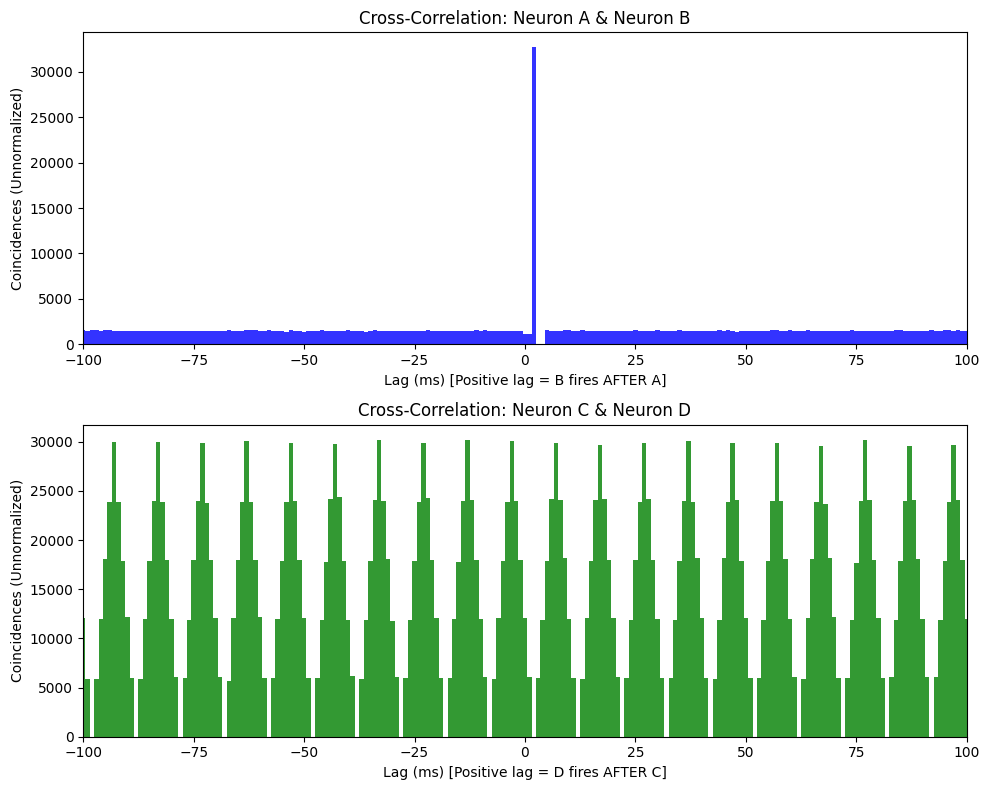

Max peak for A-B is at Lag: 2 ms, with amplitude: 32719.0


In [23]:
import numpy as np
import matplotlib.pyplot as plt

def calc_cross_corr(matrix_ref, matrix_target, max_lag=100):
    """
    מחשב קורלציה צולבת ללא נרמול.
    matrix_ref: הנוירון שאותו אנו שמים ב-t=0.
    matrix_target: הנוירון שאנו בודקים מתי ירה ביחס לרפרנס.
    """
    num_trials = matrix_ref.shape[0]
    # נכין מערך לתוצאות הקורלציה הצולבת (ממינוס max_lag עד פלוס max_lag)
    cc_sum = np.zeros(2 * max_lag + 1)
    
    for i in range(num_trials):
        # חילוץ ניסוי יחיד
        t_ref = matrix_ref[i]
        t_target = matrix_target[i]
        
        # הפונקציה correlate מחשבת את ההקבלה. 
        # כדי ש-Lag חיובי משמעותו "Target ירה אחרי Ref", נכניס את Target ראשון ו-Ref שני.
        cc = np.correlate(t_target, t_ref, mode='full')
        
        # חיתוך האזור הרלוונטי סביב האפס (-max_lag עד +max_lag)
        center = len(cc) // 2
        cc_sum += cc[center - max_lag : center + max_lag + 1]
        
    return cc_sum

max_lag = 100
lags = np.arange(-max_lag, max_lag + 1)

# 1. קורלציה צולבת בין A ל-B (כאשר A הוא הרפרנס ב-0)
cc_AB = calc_cross_corr(neuron_A, neuron_B, max_lag=max_lag)

# 2. קורלציה צולבת בין C ל-D (כאשר C הוא הרפרנס ב-0)
cc_CD = calc_cross_corr(neuron_C, neuron_D, max_lag=max_lag)

# --- יצירת הגרפים ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

axes[0].bar(lags, cc_AB, width=1, color='blue', alpha=0.8)
axes[0].set_title('Cross-Correlation: Neuron A & Neuron B')
axes[0].set_xlabel('Lag (ms) [Positive lag = B fires AFTER A]')
axes[0].set_ylabel('Coincidences (Unnormalized)')
axes[0].set_xlim(-max_lag, max_lag)

axes[1].bar(lags, cc_CD, width=1, color='green', alpha=0.8)
axes[1].set_title('Cross-Correlation: Neuron C & Neuron D')
axes[1].set_xlabel('Lag (ms) [Positive lag = D fires AFTER C]')
axes[1].set_ylabel('Coincidences (Unnormalized)')
axes[1].set_xlim(-max_lag, max_lag)

plt.tight_layout()
plt.show()

# הדפסת נתונים קריטיים לדוח עבור A ו-B
peak_lag_AB = lags[np.argmax(cc_AB)]
peak_value_AB = np.max(cc_AB)
print(f"Max peak for A-B is at Lag: {peak_lag_AB} ms, with amplitude: {peak_value_AB}")

### שלב 3.5 - ניתוח קשרים פונקציונליים (Cross-Correlation)

בסעיף זה השתמשנו בפונקציית הקורלציה הצולבת (Cross-Correlation) כדי לבחון קשרים סינפטיים בין זוגות נוירונים, תוך התייחסות להשהיה (Lag) ולאמפליטודה.

#### 1. ניתוח הקשר בין נוירון A לנוירון B:
* **קיום הקשר וסוגו:** בגרף מתקבל פיק מובהק החורג מקו הבסיס (Baseline), מה שמעיד על קשר סינפטי ישיר בין שני הנוירונים. מאחר שמדובר בפיק חיובי (עלייה בהסתברות לירי) ולא בשקע, זהו קשר **מעורר (Excitatory)**.
* **השהיה (Latency) וכיווניות:** הפיק המקסימלי התקבל ב-Lag חיובי של **2ms**. כלומר, נוירון B נוטה לירות 2 אלפיות השנייה *אחרי* שנוירון A ירה. המסקנה החד-משמעית היא ש**נוירון A הוא זה שמעורר את נוירון B**, וזמן ההשהיה הסינפטית הוא 2ms.
* **משמעות האמפליטודה והערכת קצב הירי של A:** משרעת הפיק (השטח שמעל לבייסליין של הקורלציה) מציינת את מספר הפעמים שבהם ירי של A גרם בהצלחה לירי של B. אם נניח שהקשר הוא דטרמיניסטי (הסתברות העברה של 100%), הרי שמשרעת הפיק נטו שווה לסך כל הספייקים שנוירון A הפיק במהלך כל ההקלטה. מתוך כך, נוכל להעריך את קצב הירי הממוצע של A על ידי חלוקת משרעת הפיק נטו בזמן ההקלטה הכולל (מספר ניסויים $\times$ משך ניסוי בודד).
* **שינוי בהסתברות ל-50%:** במקרה שבו נוירון A יצליח לעורר את נוירון B בהסתברות של 50% בלבד, גובה הפיק נטו (מעל הבייסליין האקראי) יפחת בדיוק לחצי, ויהיה שווה למחצית מכמות הספייקים הכוללת שנוירון A ירה.

#### 2. הסבר גרף הקורלציה הצולבת בין C ל-D:
נוירונים C ו-D אופיינו בשלבים הקודמים כנוירונים בעלי דפוס ירי מחזורי (Regular / Oscillatory neurons). 
כאשר מבצעים קורלציה צולבת בין שני אוסצילטורים, הגרף המתקבל אינו מציג פיק עירור בודד, אלא **מבנה גלי ומחזורי בעצמו** (תבנית של פיקים ועמקים עוקבים). תבנית זו אינה מעידה בהכרח על קשר סינפטי ישיר של ירי בודד, אלא משקפת את יחסי הפאזה (Phase-locking) והתאבכות התדרים בין שני נוירונים שיורים בקצב קבוע.